In [1]:

from pathlib import Path
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook

from scipy.io import loadmat
from scipy import sparse, linalg

In [2]:
def r2(y, y_hat):
    # Coefficiente di determinazione R^2
    y = np.asarray(y, dtype=float).ravel()
    y_hat = np.asarray(y_hat, dtype=float).ravel()

    residuo = y - y_hat
    denominatore = np.linalg.norm(y - y.mean())**2

    return 1.0 - np.linalg.norm(residuo)**2 / denominatore


def minimi_quadrati_normali(A, y):
    # Equazioni normali: (A^T A) beta = A^T y. (Non calcolo l'inversa per efficienza e stabilità numerica.)
    return np.linalg.solve(A.T @ A, A.T @ y)


def minimi_quadrati_qr(A, y):
    # QR ridotta: A = Q R e R beta = Q^T y.
    Q, R = np.linalg.qr(A, mode="reduced")  #QR ridotta: A = (n x m) = Q (n x m)  R (m x m)
    return np.linalg.solve(R, Q.T @ y)


def minimi_quadrati_svd(A, y, rango=None):
    # Soluzione tramite SVD: beta = V Sigma^{-1} U^T y.
    # Se 'rango' è specificato, usa solo i primi valori singolari.
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    if rango is None:
        rango = len(s)

    U_k = U[:, :rango]
    s_k = s[:rango]
    V_k = Vt[:rango, :].T

    return V_k @ ((U_k.T @ y) / s_k)



# Esercizio 1 


Shape immagine: (5120, 3840, 3)


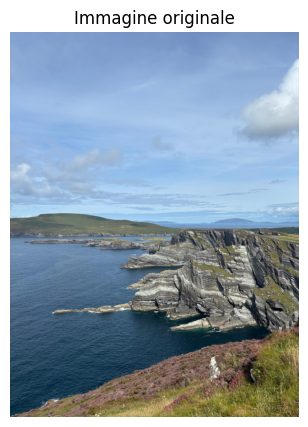

In [3]:
img = plt.imread("scogliera.jpeg").astype(float)

# Portiamo i valori in [0, 1] se l'immagine è memorizzata come uint8.
if img.max() > 1:
    img = img / 255.0

print("Shape immagine:", img.shape)

plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.title("Immagine originale")
plt.axis("off")
plt.show()


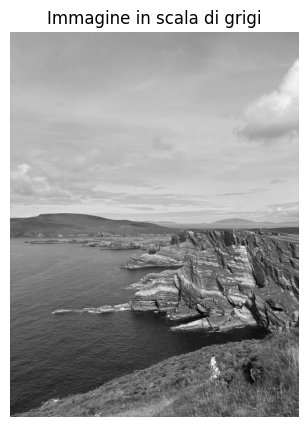

Dimensione matrice in scala di grigi: (5120, 3840)


In [4]:
if img.ndim == 3:
    A_img = img[..., :3].mean(axis=2)  
    #converto in grigi prendendo la media dei canali RGB
else:
    A_img = img.copy()

plt.figure(figsize=(7, 5))
plt.imshow(A_img, cmap="gray")
plt.title("Immagine in scala di grigi")
plt.axis("off")
plt.show()

print("Dimensione matrice in scala di grigi:", A_img.shape)


In [5]:
# SVD ridotta
U_img, s_img, Vt_img = np.linalg.svd(A_img, full_matrices=False)

# Energia cumulativa dei valori singolari
energia = np.cumsum(s_img**2) / np.sum(s_img**2)

# Primo rango che conserva almeno il 99,9% dell'energia
soglia_energia = 0.999
k_energia = np.searchsorted(energia, soglia_energia) + 1

print("Numero totale di valori singolari:", len(s_img))
print(f"Rango scelto con soglia {100*soglia_energia:.0f}%: k = {k_energia}")
print(f"Energia conservata: {100*energia[k_energia-1]:.2f}%")


Numero totale di valori singolari: 3840
Rango scelto con soglia 100%: k = 751
Energia conservata: 99.90%


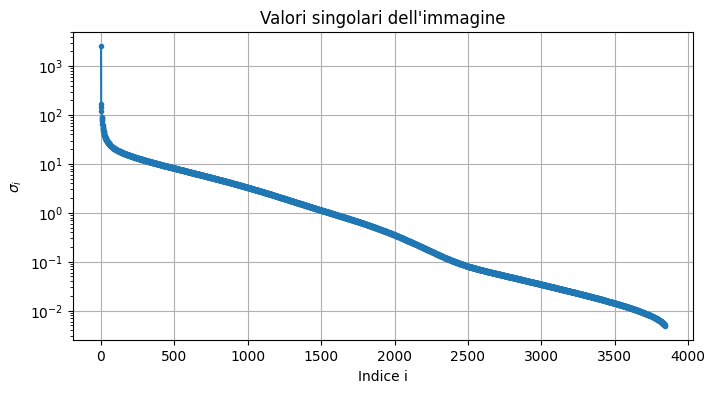

In [6]:
# Valori singolari
plt.figure(figsize=(8, 4))
plt.semilogy(np.arange(1, len(s_img) + 1), s_img, marker=".")
plt.xlabel("Indice i")
plt.ylabel(r"$\sigma_i$")
plt.title("Valori singolari dell'immagine")
plt.grid(True)
plt.show()


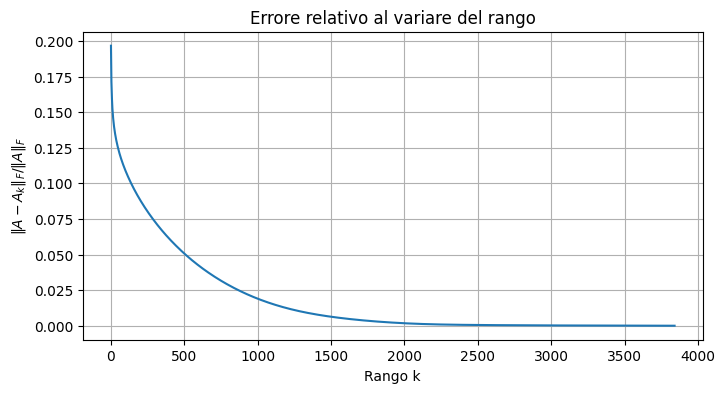

In [7]:
# Errore relativo di Frobenius per tutti i ranghi.
# Per il rango k, si sommano i quadrati dei valori singolari scartati.
sigma2 = s_img**2
energia_totale = sigma2.sum()

errori_relativi = np.zeros(len(s_img))

for k in range(1, len(s_img) + 1):
    energia_scartata = sigma2[k:].sum()
    errori_relativi[k - 1] = np.sqrt(energia_scartata / energia_totale)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(s_img) + 1), errori_relativi)
plt.xlabel("Rango k")
plt.ylabel(r"$\|A-A_k\|_F / \|A\|_F$")
plt.title("Errore relativo al variare del rango")
plt.grid(True)
plt.show()


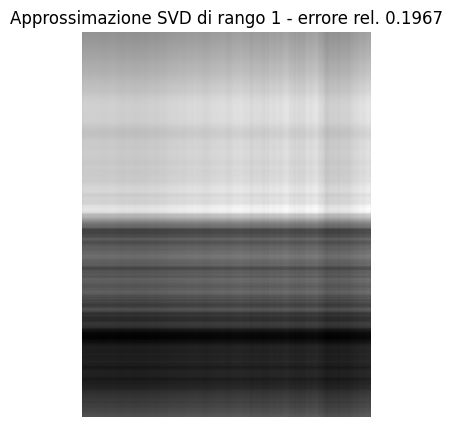

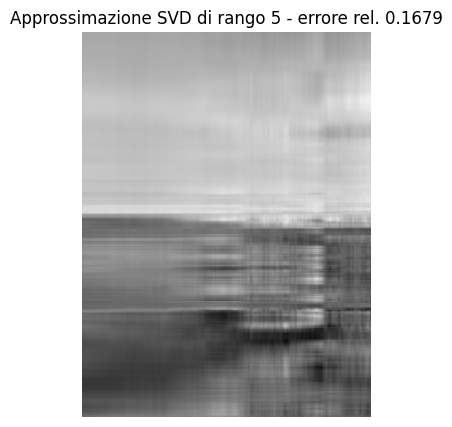

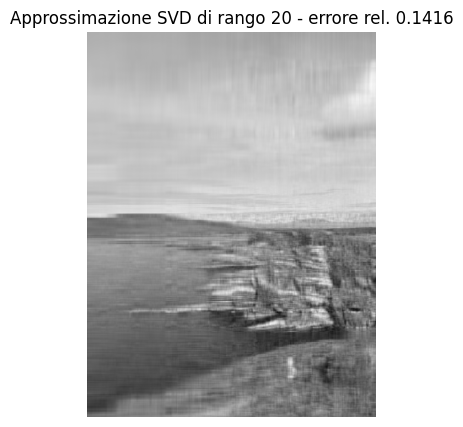

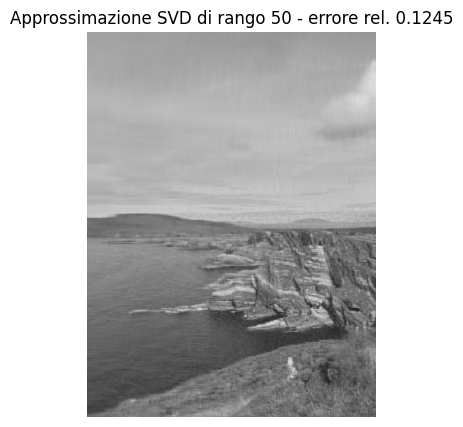

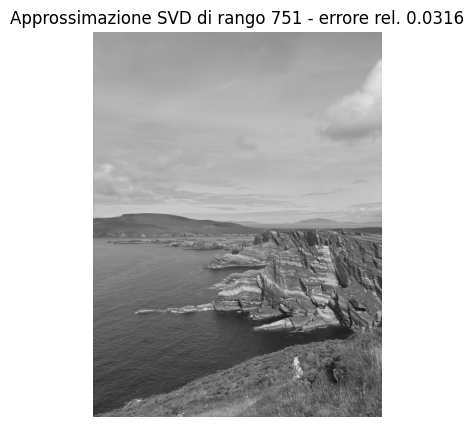

In [8]:

# Visualizziamo alcune approssimazioni.
ranghi_da_mostrare = sorted(set(
    k for k in [1, 5, k_energia, 20, 50]
    if k <= len(s_img)
))

for k in ranghi_da_mostrare:
    A_k = (U_img[:, :k] * s_img[:k]) @ Vt_img[:k, :]

    plt.figure(figsize=(7, 5))
    plt.imshow(A_k, cmap="gray")
    plt.title(
        f"Approssimazione SVD di rango {k} "
        f"- errore rel. {errori_relativi[k-1]:.4f}"
    )
    plt.axis("off")
    plt.show()


# Esercizio 2

In [36]:
rng = np.random.default_rng(7)  #seed fisso

x2 = np.linspace(-2, 2, 30)  #30 punti fra -2 e 2
x2_c = x2 - x2.mean()  #in questo caso \bar{x} = 0
# print(x2_c)
# Considero l'equazione y = 2x + 4

# Parte lineare centrata
lin = 2 * x2_c

z = rng.normal(size=x2.size)    # Rumore casuale gaussiano
z = z - z.mean()   # Lo rendo a media zero
z = z - (z @ x2_c) / (x2_c @ x2_c) * x2_c   #lo rende ortogonale a x2_c
z = z / np.linalg.norm(z)  # normalizzo

def dataset_con_r2(target_r2):
    # R^2 = ||y_hat - y_bar||_2^2 / ||y - y_bar||_2^2

    # a = y_hat - y_bar       (parte spiegata dalla regressione)
    # b = y - y_hat           (rumore / residuo)

    # R^2 = ||a||_2^2 / (||a||_2^2 + ||b||_2^2)

    # => ||b||^2 = ||a||^2 * (1 - R^2) / R^2
    # => ||b|| = ||a|| * sqrt((1 - R^2) / R^2

    eps = 1e-16

    rumore = np.linalg.norm(lin) * np.sqrt((1.0 - target_r2) / (target_r2 + eps))
    y = 4.0 + lin + rumore * z   

    A = np.column_stack([np.ones_like(x2), x2])
    beta = minimi_quadrati_qr(A, y)
    y_hat = A @ beta
    R2 = r2(y, y_hat)

    return y, y_hat, beta, R2


risultati_e2 = {}

for target in [0.0, 0.5, 1.0]:
    risultati_e2[target] = dataset_con_r2(target)

    y, y_hat, beta, R2 = risultati_e2[target]
    print(
        f"Target R^2 = {target:>3.1f}  |  "
        f"R^2 ottenuto = {R2:.12f}  |  beta = {beta}"
    )


Target R^2 = 0.0  |  R^2 ottenuto = 0.000000000000  |  beta = [4.00000003 2.        ]
Target R^2 = 0.5  |  R^2 ottenuto = 0.500000000000  |  beta = [4. 2.]
Target R^2 = 1.0  |  R^2 ottenuto = 1.000000000000  |  beta = [4. 2.]


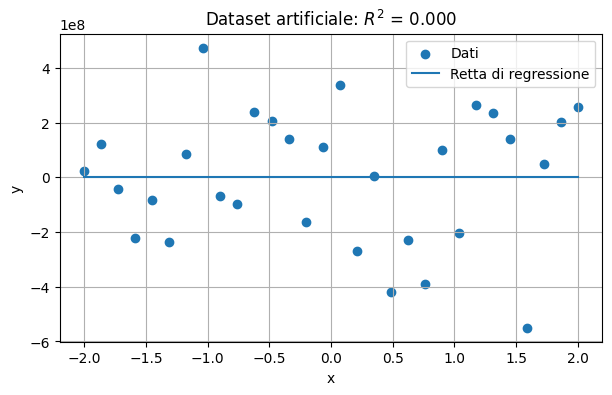

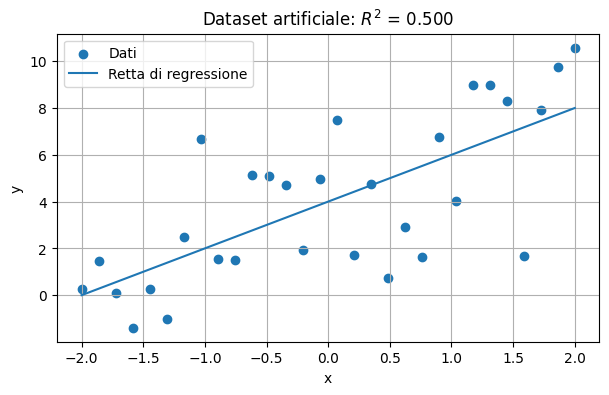

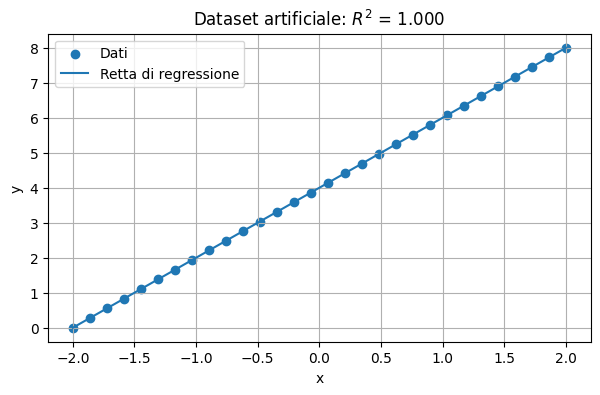

In [10]:
for target in [0.0, 0.5, 1.0]:
    y, y_hat, beta, R2 = risultati_e2[target]

    ordine = np.argsort(x2)

    plt.figure(figsize=(7, 4))
    plt.scatter(x2, y, label="Dati")
    plt.plot(x2[ordine], y_hat[ordine], label="Retta di regressione")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Dataset artificiale: $R^2$ = {R2:.3f}")
    plt.grid(True)
    plt.legend()
    plt.show()


# Esercizio 3

In [11]:
companies = loadmat("Lab1-Dataset/Companies.mat")["Companies"]

print("Shape Companies:", companies.shape)

Shape Companies: (79, 6)


In [12]:
columns = ["Assets", "Sales", "Market_Value", "Profits", "Cash_Flow", "Employees"]

In [13]:
# Colonna 2 (indice Python 2) = Market Value
y3 = companies[:, 2]

# Predittori: Assets, Sales, Profits, Cash Flow, Employees
X3 = companies[:, [0, 1, 3, 4, 5]]

# Matrice con intercetta
X3_cappello = np.column_stack([np.ones(X3.shape[0]), X3])

print("Shape X:", X3.shape)
print("Shape [1, X]:", X3_cappello.shape)
print("Shape y:", y3.shape)


Shape X: (79, 5)
Shape [1, X]: (79, 6)
Shape y: (79,)


In [14]:
# 1) Equazioni normali
beta_normali = minimi_quadrati_normali(X3_cappello, y3)

# 2) QR
beta_qr = minimi_quadrati_qr(X3_cappello, y3)

# 3) SVD
beta_svd = minimi_quadrati_svd(X3_cappello, y3)

print("beta - Equazioni normali:")
print(beta_normali)

print("\nbeta - QR:")
print(beta_qr)

print("\nbeta - SVD:")
print(beta_svd)

print("\nDifferenza max Normali vs QR:",
      np.max(np.abs(beta_normali - beta_qr)))

print("Differenza max SVD vs QR:",
      np.max(np.abs(beta_svd - beta_qr)))


beta - Equazioni normali:
[-9.56041633e+02  9.55827431e-02  2.99486396e-01  1.12522573e+01
 -4.77147000e-01  6.29761046e+00]

beta - QR:
[-9.56041633e+02  9.55827431e-02  2.99486396e-01  1.12522573e+01
 -4.77147000e-01  6.29761046e+00]

beta - SVD:
[-9.56041633e+02  9.55827431e-02  2.99486396e-01  1.12522573e+01
 -4.77147000e-01  6.29761046e+00]

Differenza max Normali vs QR: 3.069544618483633e-12
Differenza max SVD vs QR: 7.958078640513122e-13


In [15]:
def riassunto_modello(nome, beta):
    y_hat = X3_cappello @ beta
    r = y3 - y_hat
    R2 = r2(y3, y_hat)

    print(
        f"{nome:20s} | "
        f"||r||_2 = {np.linalg.norm(r):.6f} | "
        f"R^2 = {R2:.10f}"
    )

    return y_hat, r, R2


yhat_normali, r_normali, R2_normali = riassunto_modello(
    "Equazioni normali", beta_normali
)
yhat_qr, r_qr, R2_qr = riassunto_modello(
    "QR", beta_qr
)
yhat_svd, r_svd, R2_svd = riassunto_modello(
    "SVD", beta_svd
)

print("\nCondizionamento:")
print("cond([1,X])       =", np.linalg.cond(X3_cappello))
print("cond([1,X]^T[1,X]) =", np.linalg.cond(X3_cappello.T @ X3_cappello))


Equazioni normali    | ||r||_2 = 18873.605075 | R^2 = 0.9642574306
QR                   | ||r||_2 = 18873.605075 | R^2 = 0.9642574306
SVD                  | ||r||_2 = 18873.605075 | R^2 = 0.9642574306

Condizionamento:
cond([1,X])       = 16896.632808085047
cond([1,X]^T[1,X]) = 285496200.2521577


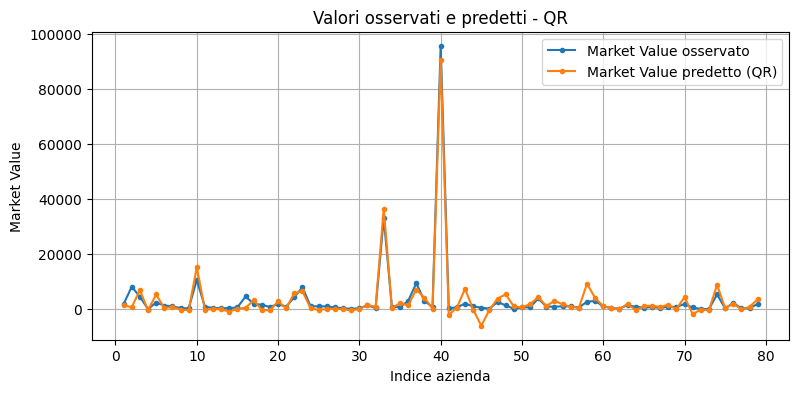

In [16]:
# Calcolo dei valori predetti con il metodo QR
yhat_qr = X3_cappello @ beta_qr

# Grafico: valori osservati e predetti dal metodo QR
indici = np.arange(1, len(y3) + 1)

plt.figure(figsize=(9, 4))

plt.plot(
    indici,
    y3,
    marker=".",
    label="Market Value osservato"
)

plt.plot(
    indici,
    yhat_qr,
    marker=".",
    label="Market Value predetto (QR)"
)

plt.xlabel("Indice azienda")
plt.ylabel("Market Value")
plt.title("Valori osservati e predetti - QR")
plt.grid(True)
plt.legend()
plt.show()

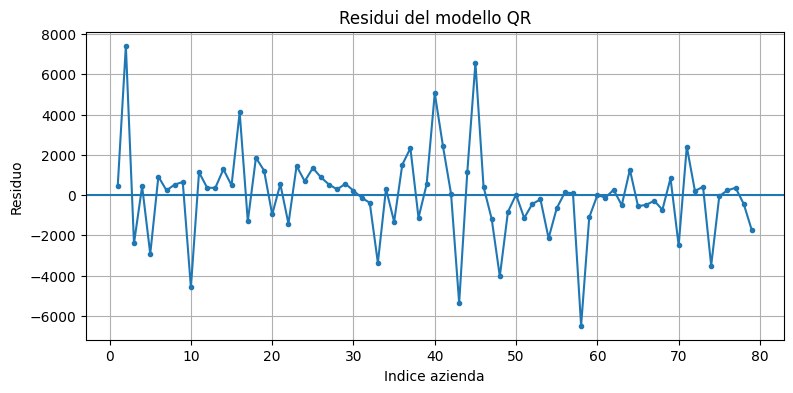

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(indici, r_qr, marker=".")
plt.axhline(0.0)
plt.xlabel("Indice azienda")
plt.ylabel("Residuo")
plt.title("Residui del modello QR")
plt.grid(True)
plt.show()


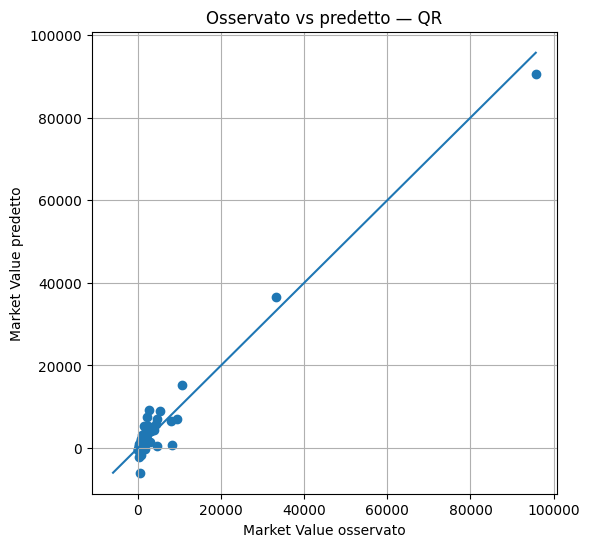

In [18]:

# Grafico 3: osservato vs predetto
lim_min = min(y3.min(), yhat_qr.min())
lim_max = max(y3.max(), yhat_qr.max())

plt.figure(figsize=(6, 6))
plt.scatter(y3, yhat_qr)
plt.plot([lim_min, lim_max], [lim_min, lim_max])
plt.xlabel("Market Value osservato")
plt.ylabel("Market Value predetto")
plt.title("Osservato vs predetto — QR")
plt.grid(True)
plt.show()


Numero osservazioni escluse: 1
Indici Python esclusi: [1]
Indici umani esclusi: [2]
Residui assoluti esclusi: [7421.13117013]

R^2 modello originale: 0.9642574305702856
R^2 modello ridotto sui dati mantenuti: 0.9715861274721111
R^2 modello ridotto su tutti i dati: 0.9617503790829038


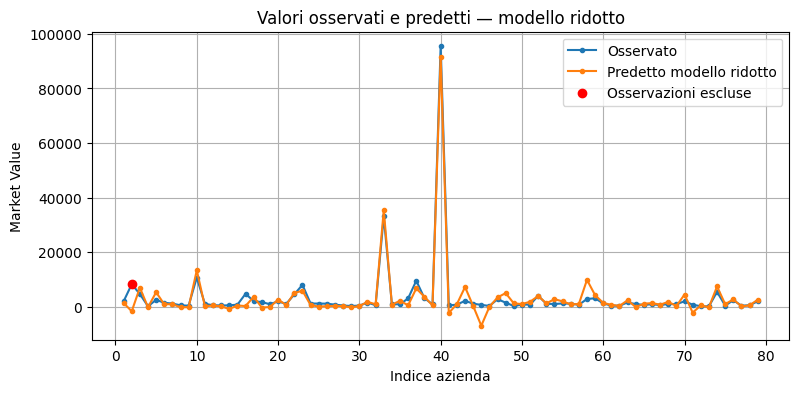

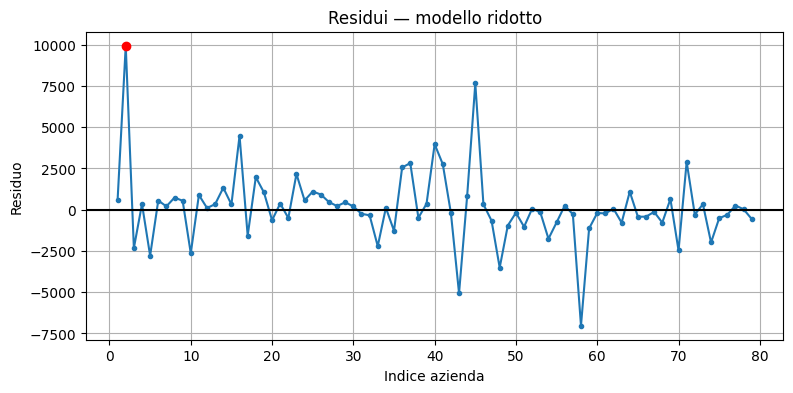

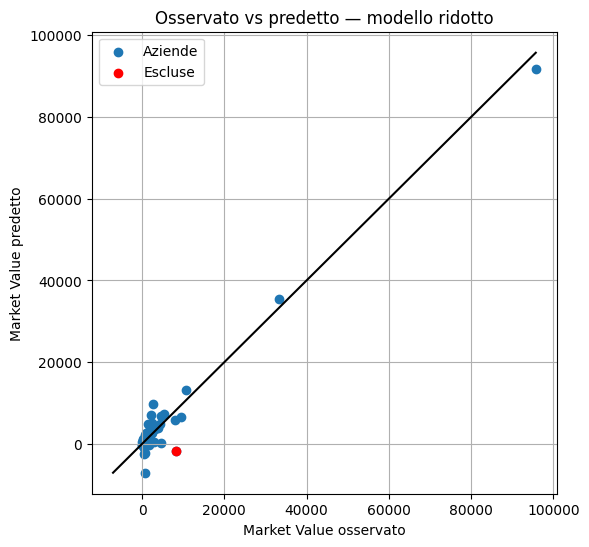

In [37]:
# Numero di osservazioni da escludere
n_escluse = 1

if not 0 <= n_escluse < len(y3):
      raise ValueError("n_escluse deve essere compreso tra 0 e len(y3)-1.")

# Indici delle osservazioni con residui assoluti maggiori
indici_ordinati = np.argsort(np.abs(r_qr))[::-1]
indici_esclusi = indici_ordinati[:n_escluse]

mask = np.ones(len(y3), dtype=bool)
mask[indici_esclusi] = False

X3_cappello_ridotto = X3_cappello[mask]
y3_ridotto = y3[mask]

beta_qr_ridotto = minimi_quadrati_qr(
      X3_cappello_ridotto,
      y3_ridotto
)

# Predizioni sul dataset ridotto e su tutto il dataset
yhat_ridotto = X3_cappello_ridotto @ beta_qr_ridotto
yhat_tutti_ridotto = X3_cappello @ beta_qr_ridotto

r_ridotto = y3_ridotto - yhat_ridotto
r_tutti_ridotto = y3 - yhat_tutti_ridotto

print("Numero osservazioni escluse:", n_escluse)
print("Indici Python esclusi:", indici_esclusi)
print("Indici umani esclusi:", indici_esclusi + 1)
print("Residui assoluti esclusi:", np.abs(r_qr[indici_esclusi]))

print("\nR^2 modello originale:", R2_qr)
print("R^2 modello ridotto sui dati mantenuti:",
        r2(y3_ridotto, yhat_ridotto))
print("R^2 modello ridotto su tutti i dati:",
        r2(y3, yhat_tutti_ridotto))

# 1. Valori osservati e predetti
plt.figure(figsize=(9, 4))
plt.plot(indici, y3, marker=".", label="Osservato")
plt.plot(indici, yhat_tutti_ridotto, marker=".",
             label="Predetto modello ridotto")
plt.scatter(
      indici_esclusi + 1,
      y3[indici_esclusi],
      color="red",
      zorder=3,
      label="Osservazioni escluse"
)
plt.xlabel("Indice azienda")
plt.ylabel("Market Value")
plt.title("Valori osservati e predetti — modello ridotto")
plt.grid(True)
plt.legend()
plt.show()

# 2. Residui
plt.figure(figsize=(9, 4))
plt.plot(indici, r_tutti_ridotto, marker=".")
plt.axhline(0.0, color="black")
plt.scatter(
      indici_esclusi + 1,
      r_tutti_ridotto[indici_esclusi],
      color="red",
      zorder=3
)
plt.xlabel("Indice azienda")
plt.ylabel("Residuo")
plt.title("Residui — modello ridotto")
plt.grid(True)
plt.show()

# 3. Osservato vs predetto
lim_min = min(y3.min(), yhat_tutti_ridotto.min())
lim_max = max(y3.max(), yhat_tutti_ridotto.max())

plt.figure(figsize=(6, 6))
plt.scatter(y3, yhat_tutti_ridotto, label="Aziende")
plt.scatter(
      y3[indici_esclusi],
      yhat_tutti_ridotto[indici_esclusi],
      color="red",
      label="Escluse"
)
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black")
plt.xlabel("Market Value osservato")
plt.ylabel("Market Value predetto")
plt.title("Osservato vs predetto — modello ridotto")
plt.grid(True)
plt.legend()
plt.show()


# Esercizio 4 


In [20]:
# Dati di training: tutte le aziende tranne l'ultima
X4_train = X3[:-1]
y4_train = y3[:-1]

# Azienda da predire: ultima riga = FW Woolworth
x4_fw = X3[-1]
y4_fw_reale = y3[-1]

A4_train = np.column_stack([np.ones(X4_train.shape[0]), X4_train])
a4_fw = np.concatenate([[1.0], x4_fw])

beta4_qr = minimi_quadrati_qr(A4_train, y4_train)
y4_fw_pred = a4_fw @ beta4_qr

errore_assoluto = abs(y4_fw_pred - y4_fw_reale)
errore_relativo = errore_assoluto / abs(y4_fw_reale)

print("Market Value reale FW Woolworth:", y4_fw_reale)
print("Predizione QR:", y4_fw_pred)
print("Errore assoluto:", errore_assoluto)
print("Errore relativo:", errore_relativo)


Market Value reale FW Woolworth: 1921.0
Predizione QR: 3879.915624560991
Errore assoluto: 1958.915624560991
Errore relativo: 1.0197374412082203


In [21]:
# Miglioramento 

# Centro le variabili predittive
x_media = X4_train.mean(axis=0)
X4_c = X4_train - x_media

# Centro anche la variabile risposta
y_media = y4_train.mean()
y4_c = y4_train - y_media

# SVD della matrice centrata
U4, s4, Vt4 = np.linalg.svd(
    X4_c,
    full_matrices=False
)

print("Valori singolari:")
print(s4)

Valori singolari:
[96186.33120429 35007.30476683  6712.16877975   772.47373485
   187.33388372]


In [22]:
# Energia cumulativa dei valori singolari
energia4 = np.cumsum(s4**2) / np.sum(s4**2)

# Scelgo k in modo da conservare almeno l'85% dell'energia
soglia4 = 0.85
k4 = np.searchsorted(energia4, soglia4) + 1

print("Energia cumulativa:")
print(energia4)

print(
    f"Con soglia {100*soglia4:.0f}% scegliamo k = {k4}"
)

Energia cumulativa:
[0.87919837 0.99565856 0.99993996 0.99999667 1.        ]
Con soglia 85% scegliamo k = 1


In [23]:
# Liste per salvare predizioni ed errori
predizioni_pcr = []
errori_pcr = []

for k in range(1, X4_train.shape[1] + 1):

    # Prime k componenti della SVD
    U_k = U4[:, :k]
    s_k = s4[:k]
    V_k = Vt4[:k, :].T

    # Soluzione PCR:
    # beta_k = V_k Sigma_k^(-1) U_k^T y_c
    beta_k = V_k @ (
        (U_k.T @ y4_c) / s_k
    )

    # Predizione sul dato centrato, poi riaggiungo la media
    pred_k = (
        y_media
        + (x4_fw - x_media) @ beta_k
    )

    # Errore assoluto
    err_k = abs(
        pred_k - y4_fw_reale
    )

    predizioni_pcr.append(pred_k)
    errori_pcr.append(err_k)

    print(
        f"k = {k} | "
        f"predizione = {pred_k:.3f} | "
        f"errore = {err_k:.3f}"
    )

k = 1 | predizione = 1802.231 | errore = 118.769
k = 2 | predizione = 5505.432 | errore = 3584.432
k = 3 | predizione = 2811.197 | errore = 890.197
k = 4 | predizione = 3411.200 | errore = 1490.200
k = 5 | predizione = 3879.916 | errore = 1958.916


In [24]:
# Risultato ottenuto con il rango scelto tramite energia
predizione_pcr = predizioni_pcr[k4 - 1]
errore_pcr = errori_pcr[k4 - 1]

print("Rango scelto:", k4)
print("Predizione PCR:", predizione_pcr)
print("Errore assoluto PCR:", errore_pcr)
print(
    "Errore relativo PCR:",
    errore_pcr / abs(y4_fw_reale)
)

Rango scelto: 1
Predizione PCR: 1802.2310845227612
Errore assoluto PCR: 118.7689154772388
Errore relativo PCR: 0.06182660878565269


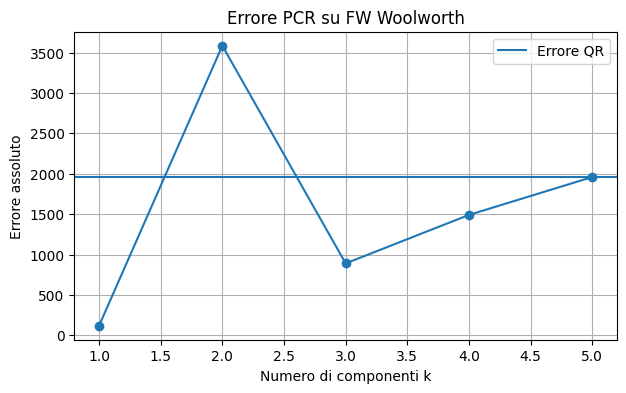

In [25]:
# Confronto dell'errore PCR al variare di k
plt.figure(figsize=(7, 4))

plt.plot(
    np.arange(1, len(errori_pcr) + 1),
    errori_pcr,
    marker="o"
)

# Errore del modello QR completo
plt.axhline(
    errore_assoluto,
    label="Errore QR"
)

plt.xlabel("Numero di componenti k")
plt.ylabel("Errore assoluto")
plt.title("Errore PCR su FW Woolworth")

plt.grid(True)
plt.legend()
plt.show()

# Esercizio 5 


In [26]:
# Carico la matrice termine-documento.
# Ogni riga = una parola, ogni colonna = un documento.
A_med = loadmat("Lab1-Dataset/A_med.mat")["A_med"].tocsc()

# Carico il dizionario delle parole.
dict_med = loadmat("Lab1-Dataset/dict_med.mat")["dict_med"]


# Converto gli elementi del dizionario in stringhe pulite.
dict_med = np.array([
    str(parola).strip()
    for parola in dict_med
])


print("Shape A_med:", A_med.shape)
print("Numero parole nel dizionario:", len(dict_med))

Shape A_med: (5735, 1033)
Numero parole nel dizionario: 5735


In [27]:
# Prima colonna di A_med:
# contiene le frequenze delle parole nel primo documento.
y5 = A_med[:, 0].toarray().ravel()

# Cerco gli indici delle parole che compaiono almeno una volta.
indici_nonnulli = np.flatnonzero(y5)

# Frequenze delle sole parole presenti nel documento.
frequenze = y5[indici_nonnulli]

# Parole corrispondenti agli stessi indici.
parole = dict_med[indici_nonnulli]

In [28]:
print(
    "Numero di parole presenti nel primo documento:",
    len(indici_nonnulli)
)

print("\nParole e frequenze:")

# Associo a ogni indice:
# - parola del dizionario
# - frequenza nel documento
for i, parola, freq in zip(
    indici_nonnulli,
    parole,
    frequenze
):
    print(
        f"{i:4d}  "
        f"{parola:20s}  "
        f"{freq:g}"
    )

Numero di parole presenti nel primo documento: 26

Parole e frequenze:
  73  acids                 1
 340  appears               1
 885  coefficients          2
 901  collected             1
1124  correlation           3
1125  correlations          1
1307  delivery              3
1333  dependent             2
1386  determined            1
1963  fatty                 1
1993  fetal                 6
1998  ffa                   3
2118  free                  1
2207  glucose               4
2975  level                 4
2976  levels                4
2999  lines                 1
3158  maternal              6
3527  obtained              1
3866  plasma                3
4382  regression            1
4795  significant           1
4830  size                  1
4843  slightly              1
4845  slopes                1
5014  strongly              1


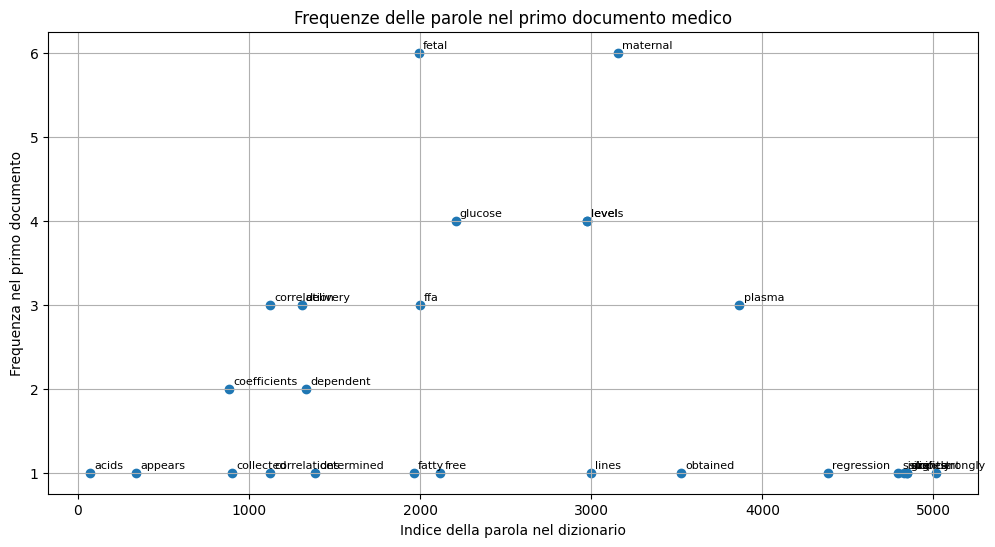

In [29]:
# Grafico analogo alla Figura 1 del testo del laboratorio.
plt.figure(figsize=(12, 6))
plt.scatter(indici_nonnulli, frequenze)

for i, parola, freq in zip(indici_nonnulli, parole, frequenze):
    plt.annotate(
        parola,
        (i, freq),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Indice della parola nel dizionario")
plt.ylabel("Frequenza nel primo documento")
plt.title("Frequenze delle parole nel primo documento medico")
plt.grid(True)
plt.show()


# Esercizio 6 

In [30]:
# Costruiamo il problema dell'Esercizio 6 mantenendo la matrice sparsa.
y6 = A_med[:, 0].toarray().ravel()
X6 = A_med[:, 1:]

colonna_uno = sparse.csc_matrix(np.ones((X6.shape[0], 1)))
A6 = sparse.hstack([colonna_uno, X6], format="csc")

print("Shape A6 =", A6.shape)
print("Numero elementi non nulli =", A6.nnz)
print("Densità =", A6.nnz / (A6.shape[0] * A6.shape[1]))


Shape A6 = (5735, 1033)
Numero elementi non nulli = 56883
Densità = 0.00960171363319101


In [ ]:
def lsqr(A, b, imax=150, tol=0.05):
    m, n = A.shape

    b = np.asarray(b, dtype=float).ravel()

    # beta = ||b||
    # u = b / beta
    beta = np.linalg.norm(b)
    norma_b = beta

    x = np.zeros(n)

    if beta == 0:
        return x, np.array([0.0])

    u = b / beta

    # v = A^T u
    # alfa = ||v||
    # v = v / alfa
    v = np.asarray(A.T @ u).ravel()
    alfa = np.linalg.norm(v)

    if alfa == 0:
        return x, np.array([1.0])

    v = v / alfa

    # Inizializzazione come nelle slide
    phi = beta
    rho = alfa

    i = 0
    d = v.copy()

    residui = [1.0]
    res = beta

    # Iterazioni LSQR
    while i < imax and res / norma_b > tol:

        i = i + 1

        # Bidiagonalizzazione di Golub-Kahan
        # beta_{k+1} u_{k+1} = A v_k - alfa_k u_k

        u = np.asarray(A @ v).ravel() - alfa * u  #ravel trasforma colonna in riga per python
        beta = np.linalg.norm(u)

        if beta == 0:
            break

        u = u / beta

        # alfa_{k+1} v_{k+1}
        # = A^T u_{k+1} - beta_{k+1} v_k

        v = np.asarray(A.T @ u).ravel() - beta * v
        alfa = np.linalg.norm(v)

        if alfa > 0:
            v = v / alfa


        # Rotazione di Givens

        rho1 = np.sqrt(rho**2 + beta**2)

        c = rho / rho1
        s = beta / rho1

        theta = s * alfa
        rho = -c * alfa

        phi1 = c * phi
        phi = s * phi

        # Update 

        x = x + (phi1 / rho1) * d

        d = v - (theta / rho1) * d

        # Residuo
        res = abs(phi)

        # Per il grafico calcolo anche il residuo vero
        r = b - np.asarray(A @ x).ravel()
        residui.append(np.linalg.norm(r) / norma_b)

    return x, np.asarray(residui)

In [32]:
t0 = perf_counter()
beta_lsqr, storia_residui = lsqr(A6, y6, imax=150)
tempo_lsqr = perf_counter() - t0

print("Tempo LSQR:", tempo_lsqr, "secondi")
print("Numero iterazioni:", len(storia_residui) - 1)
print("Residuo relativo finale:", storia_residui[-1])


Tempo LSQR: 0.059141800011275336 secondi
Numero iterazioni: 150
Residuo relativo finale: 0.5417422685198192


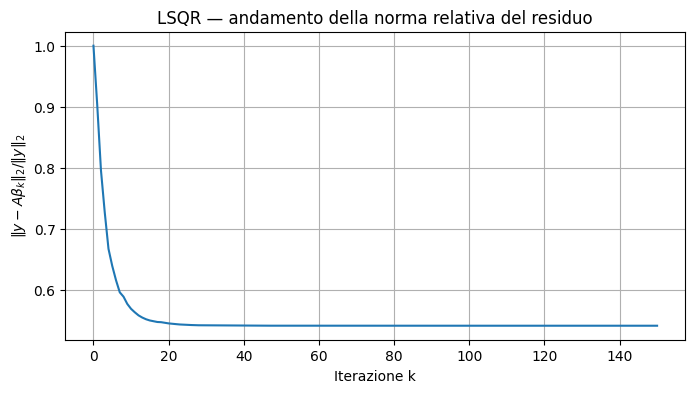

In [33]:

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(storia_residui)), storia_residui)
plt.xlabel("Iterazione k")
plt.ylabel(r"$\|y-A\beta_k\|_2 / \|y\|_2$")
plt.title("LSQR — andamento della norma relativa del residuo")
plt.grid(True)
plt.show()


In [ ]:
#CONFRONTO
# ---------- Equazioni normali ----------
t0 = perf_counter()

G6 = (A6.T @ A6).toarray()
rhs6 = np.asarray(A6.T @ y6).ravel()
beta6_normali = np.linalg.solve(G6, rhs6)

tempo6_normali = perf_counter() - t0
res6_normali = np.linalg.norm(
    y6 - np.asarray(A6 @ beta6_normali).ravel()
) / np.linalg.norm(y6)


# ---------- QR ----------
t0 = perf_counter()

A6_dense_qr = A6.toarray()
Q6, R6 = np.linalg.qr(A6_dense_qr, mode="reduced")
beta6_qr = np.linalg.solve(R6, Q6.T @ y6)

tempo6_qr = perf_counter() - t0
res6_qr = np.linalg.norm(y6 - A6_dense_qr @ beta6_qr) / np.linalg.norm(y6)

del Q6, R6, A6_dense_qr


# ---------- SVD ----------
t0 = perf_counter()

A6_dense_svd = A6.toarray()
U6, s6, Vt6 = linalg.svd(
    A6_dense_svd,
    full_matrices=False,
    lapack_driver="gesdd"
)
beta6_svd = Vt6.T @ ((U6.T @ y6) / s6)

tempo6_svd = perf_counter() - t0
res6_svd = np.linalg.norm(y6 - A6_dense_svd @ beta6_svd) / np.linalg.norm(y6)

del U6, Vt6, A6_dense_svd


print("Metodo              Tempo [s]      Residuo relativo")
print("-" * 58)
print(f"LSQR               {tempo_lsqr:10.4f}      {storia_residui[-1]:.12f}")
print(f"Equazioni normali  {tempo6_normali:10.4f}      {res6_normali:.12f}") 
print(f"QR                 {tempo6_qr:10.4f}      {res6_qr:.12f}")
print(f"SVD                {tempo6_svd:10.4f}      {res6_svd:.12f}")


Metodo              Tempo [s]      Residuo relativo
----------------------------------------------------------
LSQR                   0.0591      0.541742268520
Equazioni normali      0.0949      0.541742268515
QR                     1.5921      0.541742268515
SVD                    1.6877      0.541742268515


In [35]:
# Confronto delle soluzioni con QR come riferimento.
def differenza_relativa(beta, beta_ref):
    return np.linalg.norm(beta - beta_ref) / np.linalg.norm(beta_ref)

print("Differenza relativa LSQR vs QR:",
      differenza_relativa(beta_lsqr, beta6_qr))

print("Differenza relativa Normali vs QR:",
      differenza_relativa(beta6_normali, beta6_qr))

print("Differenza relativa SVD vs QR:",
      differenza_relativa(beta6_svd, beta6_qr))

print("\nCondizionamento del problema denso, ricavato dai valori singolari SVD:")
print("cond(A6) =", s6[0] / s6[-1])


Differenza relativa LSQR vs QR: 9.558143989330203e-06
Differenza relativa Normali vs QR: 1.3948252228989727e-14
Differenza relativa SVD vs QR: 5.0092979052326035e-15

Condizionamento del problema denso, ricavato dai valori singolari SVD:
cond(A6) = 73.24350736812687
